# Spectral gap calculations Tutorial

Here we assume you have set up your python environment, with the latest version of qemcmc (0.1 at time of writing) and its requirements.

## Imports

In [2]:
import numpy as np
from matplotlib import pyplot as plt
from qemcmc.spectralgap import SpectralGap
from tqdm.notebook import tqdm
from qemcmc.sampler import ClassicalProposal, QeProposal
import numpy as np
from qemcmc.model import ModelMaker


The package also comes with inbuilt functionality to calculate the spectral gap of each proposal method.

The spectral gap is a very good measure of the convergance capabilities of a given Markov Chain. It is inversely proportional to the thermalisation time, so studying the average spectral gap of many chains (on many models) can allow us to compare classical and quantum methods


In [3]:

# Define parameters of experiment
temp = 0.1
n_list = [2,3,4,5,6,7,8]

# Number of models to test at each n
number_of_models = 20

# Type of model to test
model_type = "Fully Connected Ising"


q_spec_gaps = []
uni_spec_gaps = []
loc_spec_gaps = []



# Loop over the number of spins in the system
pbar = tqdm(n_list, desc="Looping through n", bar_format = "{l_bar}|{bar}| {n_fmt}/{total_fmt}{postfix}")
for n in pbar:
    pbar.set_description(f"Currently on system size, n: {n}")

    q_spec_gaps_n = []
    uni_spec_gaps_n = []
    loc_spec_gaps_n = []
    # Loop over the number of models to test
    
    pbar_2 = tqdm(list((range(number_of_models))), total=number_of_models, desc="Looping through models")
    for i in pbar_2:
        pbar_2.set_description(f"Looping through models, currently on number: {i+1}")
        
        # Build an Ising model to test the algorithms on
        model = ModelMaker(n, model_type, None).model
        initial_states = model.initial_state
        
        # Run classical (uniform and local) chains
        classical_uniform_proposal = ClassicalProposal(model, method = "uniform")
        spec_gap_finder = SpectralGap(classical_uniform_proposal, model)
        uni_spec_gaps_n.append(spec_gap_finder.find_spec_gap())
        
        classical_local_proposal = ClassicalProposal(model, method = "local")
        spec_gap_finder = SpectralGap(classical_local_proposal, model)
        loc_spec_gaps_n.append(spec_gap_finder.find_spec_gap())
        
        # Run the quantum algorithm
        quantum_proposal = QeProposal(model, gamma=0.45, time=5)
        spec_gap_finder = SpectralGap(quantum_proposal, model)
        q_spec_gaps_n.append(spec_gap_finder.find_spec_gap())
    
    # Append the results to the list
    uni_spec_gaps.append(np.mean(uni_spec_gaps_n))
    loc_spec_gaps.append(np.mean(loc_spec_gaps_n))
    q_spec_gaps.append(np.mean(q_spec_gaps_n))
    
    
    
    


Looping through n:   0%||          | 0/7

Looping through models:   0%|          | 0/20 [00:00<?, ?it/s]

TypeError: '<' not supported between instances of 'list' and 'int'

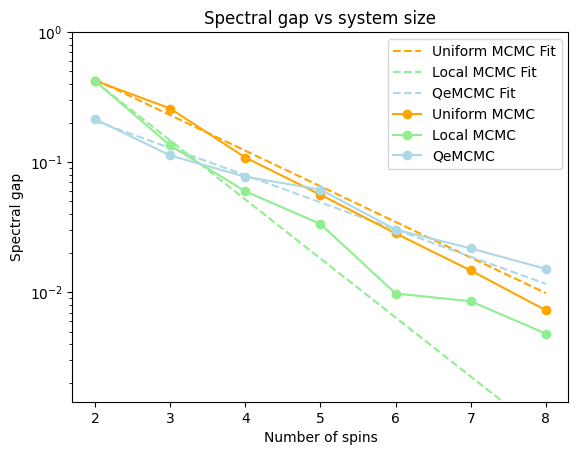

Uniform MCMC fit parameters:  [1.52501439 0.63013596]
Local MCMC fit parameters:  [3.37706684 1.04458181]
QeMCMC fit parameters:  [0.54344286 0.48069333]


In [ ]:
from scipy.optimize import curve_fit
import matplotlib.pyplot as plt
# Define the exponential decay function
def exp_decay(x, a, b):
    return a * np.exp(-b * x)

# Fit the uniform MCMC data
uni_params, _ = curve_fit(exp_decay, n_list, uni_spec_gaps)
plt.plot(n_list, exp_decay(np.array(n_list), *uni_params), linestyle='--', label="Uniform MCMC Fit", color = "orange")

# Fit the local MCMC data
loc_params, _ = curve_fit(exp_decay, n_list, loc_spec_gaps)
plt.plot(n_list, exp_decay(np.array(n_list), *loc_params), linestyle='--', label="Local MCMC Fit", color = "lightgreen")

# Fit the QeMCMC data
q_params, _ = curve_fit(exp_decay, n_list, q_spec_gaps)
plt.plot(n_list, exp_decay(np.array(n_list), *q_params), linestyle='--', label="QeMCMC Fit", color = "lightblue")




# Plot results
plt.plot(n_list, uni_spec_gaps, marker='o', label = "Uniform MCMC", color = "orange")
plt.plot(n_list, loc_spec_gaps, marker='o', label = "Local MCMC", color = "lightgreen")
plt.plot(n_list, q_spec_gaps, marker='o', label = "QeMCMC", color = "lightblue")

plt.legend()
plt.xlabel("Number of spins")
plt.ylabel("Spectral gap")
plt.title("Spectral gap vs system size")
plt.yscale("log")
plt.ylim(max(1e-4,np.min(loc_spec_gaps))*0.3, 1e0)
plt.show()


print("Uniform MCMC fit parameters: ", uni_params)
print("Local MCMC fit parameters: ", loc_params)
print("QeMCMC fit parameters: ", q_params)
